In [1]:
#loaading libs

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# loading dataset

df = pd.read_csv("/content/marketing_campaign.csv", sep="\t")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.shape

(2240, 29)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [7]:
#checking mising valued
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [8]:
#fill mising values
df["Income"].fillna(df["Income"].median(), inplace=True)

In [9]:
#remove unnecessary column
df.drop(["ID"], axis=1, inplace=True)

In [10]:
# feature engineering
current_year = 2026
df["Age"] = current_year - df["Year_Birth"]

df.drop("Year_Birth", axis=1, inplace=True)

In [11]:
#encode catagorical variables
df = pd.get_dummies(
    df,
    columns=["Education", "Marital_Status"],
    drop_first=True
)

In [12]:
#drop data column
df.drop("Dt_Customer", axis=1, inplace=True)

In [13]:
# standardize features
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [14]:
# apply pca
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [15]:
#explained varience
print(pca.explained_variance_ratio_)

[0.19261917 0.06444686]


In [16]:
#elbow meathod
wcss = []

for k in range(1,11):
    model = KMeans(
        n_clusters=k,
        random_state=42
    )
    model.fit(pca_data)
    wcss.append(model.inertia_)

In [17]:
#silhoutte score
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(pca_data)

    score = silhouette_score(
        pca_data,
        labels
    )

    print(k, score)

2 0.5185863003444512
3 0.48304482643238295
4 0.41205682250106496
5 0.37750814935434546
6 0.38018184484206446
7 0.36557513093973376
8 0.33743439386743673
9 0.337437426586309
10 0.34774941437158446


In [18]:
#train final model
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(pca_data)

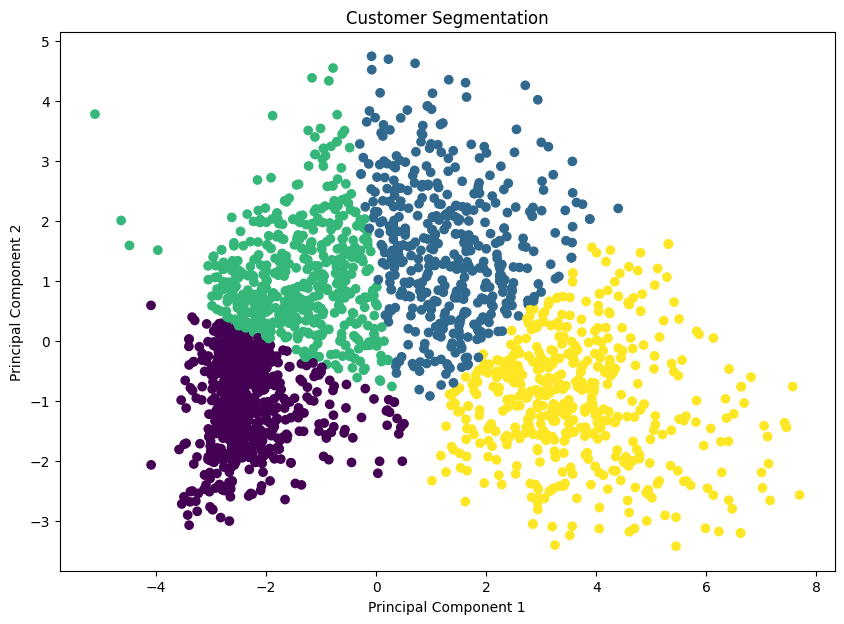

In [19]:
#visvual clusters

plt.figure(figsize=(10,7))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation")

plt.show()

In [20]:
#business persona
cluster_summary = df.groupby("Cluster").mean()

print(cluster_summary)

               Income   Kidhome  Teenhome    Recency    MntWines  MntFruits  \
Cluster                                                                       
0        31578.184798  0.849372  0.231520  49.577406   26.251046   6.086471   
1        63399.321272  0.105263  0.868421  49.548246  589.478070  29.916667   
2        46211.470109  0.570652  0.909420  48.063406  155.251812   6.840580   
3        77578.028155  0.044660  0.135922  49.190291  597.073786  72.106796   

         MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  \
Cluster                                                                     
0              21.675035         8.656904          5.810321     16.000000   
1             190.541667        40.052632         31.938596     65.583333   
2              50.952899        10.592391          6.891304     27.724638   
3             472.648544       104.347573         73.955340     81.411650   

         ...  Education_Graduation  Education_Master  Educatio